In [ ]:
install.packages("ghyp")

Installation du package dans 'C:/Users/gabri/AppData/Local/R/win-library/4.5'
(car 'lib' n'est pas spécifié)

installation des dépendances 'numDeriv', 'MASS'




le package 'numDeriv' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'MASS' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'ghyp' a été décompressé et les sommes MD5 ont été vérifiées avec succés

Les packages binaires téléchargés sont dans
	C:\Users\gabri\AppData\Local\Temp\RtmpYhPams\downloaded_packages


In [2]:
library(ghyp)

Warning message:
"le package 'ghyp' a été compilé avec la version R 4.5.3"
Le chargement a nécessité le package : numDeriv

Le chargement a nécessité le package : MASS

Warning message:
"le package 'MASS' a été compilé avec la version R 4.5.3"


In [ ]:
dLdf <- read.csv("../data/increments/temp_inc.csv")
names(dLdf) <- "dL"
x <- dLdf$dL

In [18]:
fit_g <- fit.gaussuv(x)
summary(fit_g)

Gaussian Distribution:

Parameters:
           mu         sigma 
-1.041891e-05  4.401425e-01 

Call:
fit.gaussuv(data = x)

Optimization information:
log-Likelihood:                -31472.72 
AIC:                           62949.43 
Fitted parameters:             mu, sigma;  (Number: 2)
Number of iterations:          0 
Converged:                     TRUE 


In [ ]:
fit_nig <- fit.NIGuv(x)

[1] "Llh: -2.86648138412970E+04; Pars:  5.000000E-01,  1.821049E-02,  3.175022E-01,  0.000000E+00"
[1] "Llh: -2.84356842490979E+04; Pars:  5.607836E-01,  1.821049E-02,  3.175022E-01,  0.000000E+00"
[1] "Llh: -3.29459566334055E+04; Pars:  5.000000E-01,  1.329375E-01,  3.175022E-01,  0.000000E+00"
[1] "Llh: -2.69300587281052E+04; Pars:  5.000000E-01,  1.821049E-02,  3.561001E-01,  0.000000E+00"
[1] "Llh: -3.39208478441771E+04; Pars:  5.000000E-01,  1.821049E-02,  3.175022E-01,  1.147271E-01"
[1] "Llh: -2.81582747171978E+04; Pars:  5.295204E-01,  7.557402E-02,  3.362477E-01, -1.147271E-01"
[1] "Llh: -2.76925128341472E+04; Pars:  5.219808E-01,  6.123314E-02,  3.314601E-01, -5.736353E-02"
[1] "Llh: -3.09837102805019E+04; Pars:  5.410344E-01, -7.500525E-02,  3.435592E-01, -2.868176E-02"
[1] "Llh: -2.84393983140776E+04; Pars:  5.304704E-01, -2.301955E-02,  3.368510E-01, -2.151132E-02"
[1] "Llh: -2.68951261960700E+04; Pars:  5.572762E-01,  1.910679E-02,  3.538728E-01, -3.943743E-02"
[1] "Llh: 

In [20]:
summary(fit_nig)

Asymmetric Normal Inverse Gaussian Distribution:

Parameters:
  alpha.bar          mu       sigma       gamma 
 0.60897393  0.04473921  0.42894509 -0.04478084 

Call:
fit.NIGuv(data = x)

Optimization information:
log-Likelihood:                -25547.46 
AIC:                           51102.92 
Fitted parameters:             alpha.bar, mu, sigma, gamma;  (Number: 4)
Number of iterations:          205 
Converged:                     TRUE 


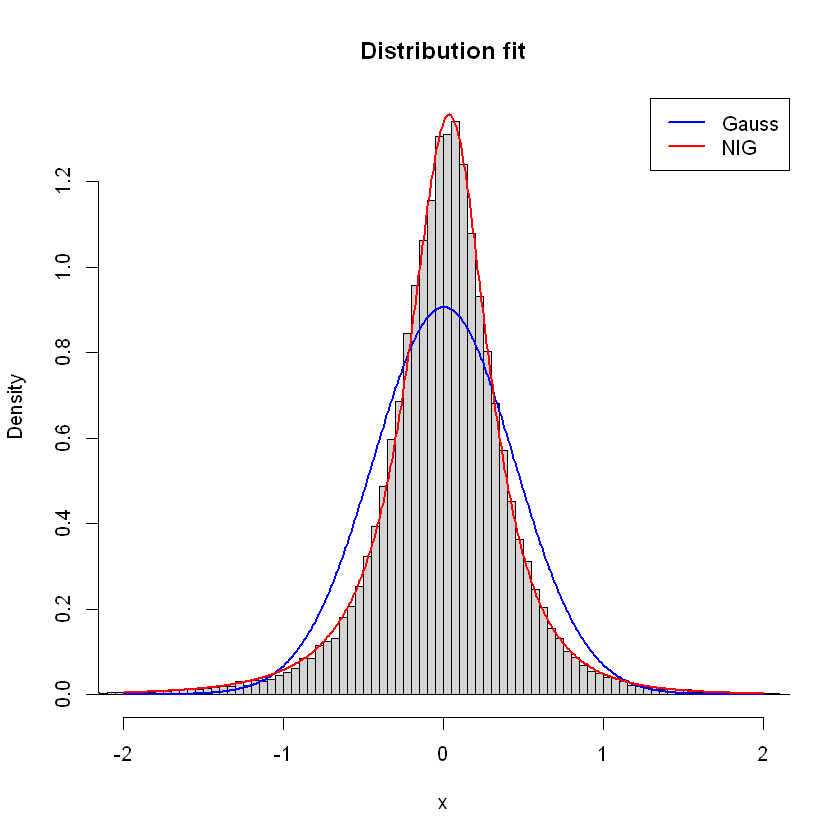

In [23]:
hist(x, breaks = 300, freq = FALSE, col = "lightgray",
     main = "Distribution fit",
     xlab = "x",
     xlim = c(-2, 2))

xx <- seq(-2, 2, length.out = 500)

lines(xx, dnorm(xx, mean = mean(x), sd = sd(x)),
      col = "blue", lwd = 2)

lines(xx, dghyp(xx, object = fit_nig),
      col = "red", lwd = 2)

legend("topright",
       legend = c("Gauss", "NIG"),
       col = c("blue", "red"),
       lwd = 2)

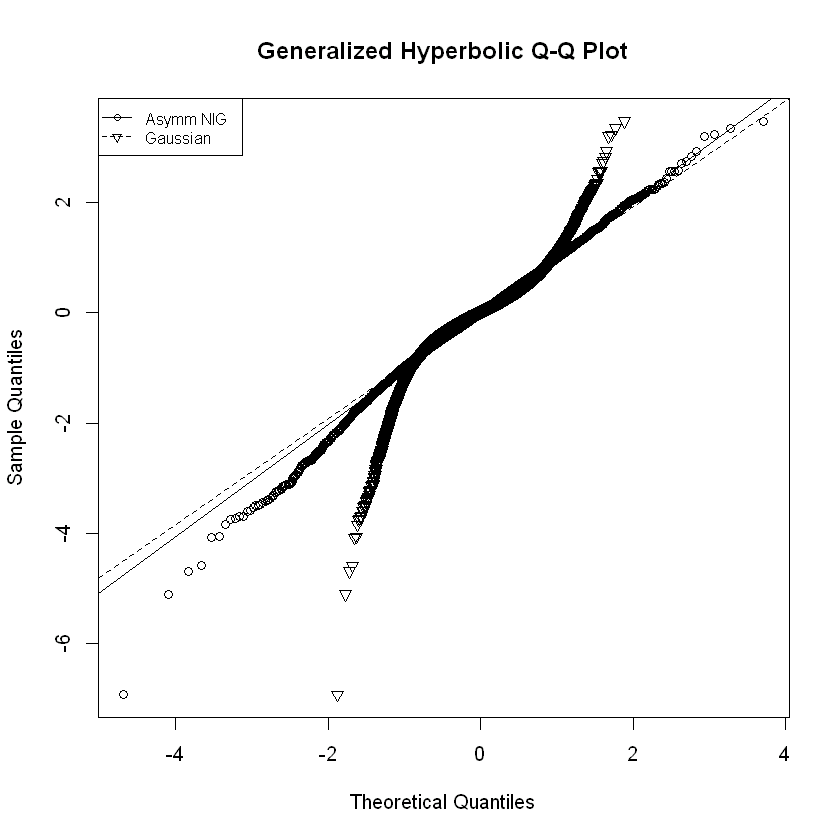

In [24]:
qqghyp(fit_nig)

In [25]:
temp_resid <- read.csv("../data/deseasonalised/temp_resid.csv")
temp_res <- temp_resid$temp_deseasoned

price_resid <- read.csv("../data/deseasonalised/price_resid.csv")
price_res <- price_resid$price_deseasoned

In [43]:
fit_arma <- arima(price_res, order = c(2,0,1), include.mean = FALSE)

In [44]:
fit_arma


Call:
arima(x = price_res, order = c(2, 0, 1), include.mean = FALSE)

Coefficients:
         ar1     ar2     ma1
      0.8554  0.0204  0.3265
s.e.  0.0191  0.0179  0.0179

sigma^2 estimated as 202.1:  log likelihood = -107055,  aic = 214118

In [42]:
fit_arma


Call:
arima(x = price_res, order = c(3, 0, 1), include.mean = FALSE)

Coefficients:
         ar1      ar2     ar3      ma1
      2.0457  -1.3453  0.2944  -0.8966
s.e.  0.0095   0.0129  0.0059   0.0083

sigma^2 estimated as 199.2:  log likelihood = -106863,  aic = 213736